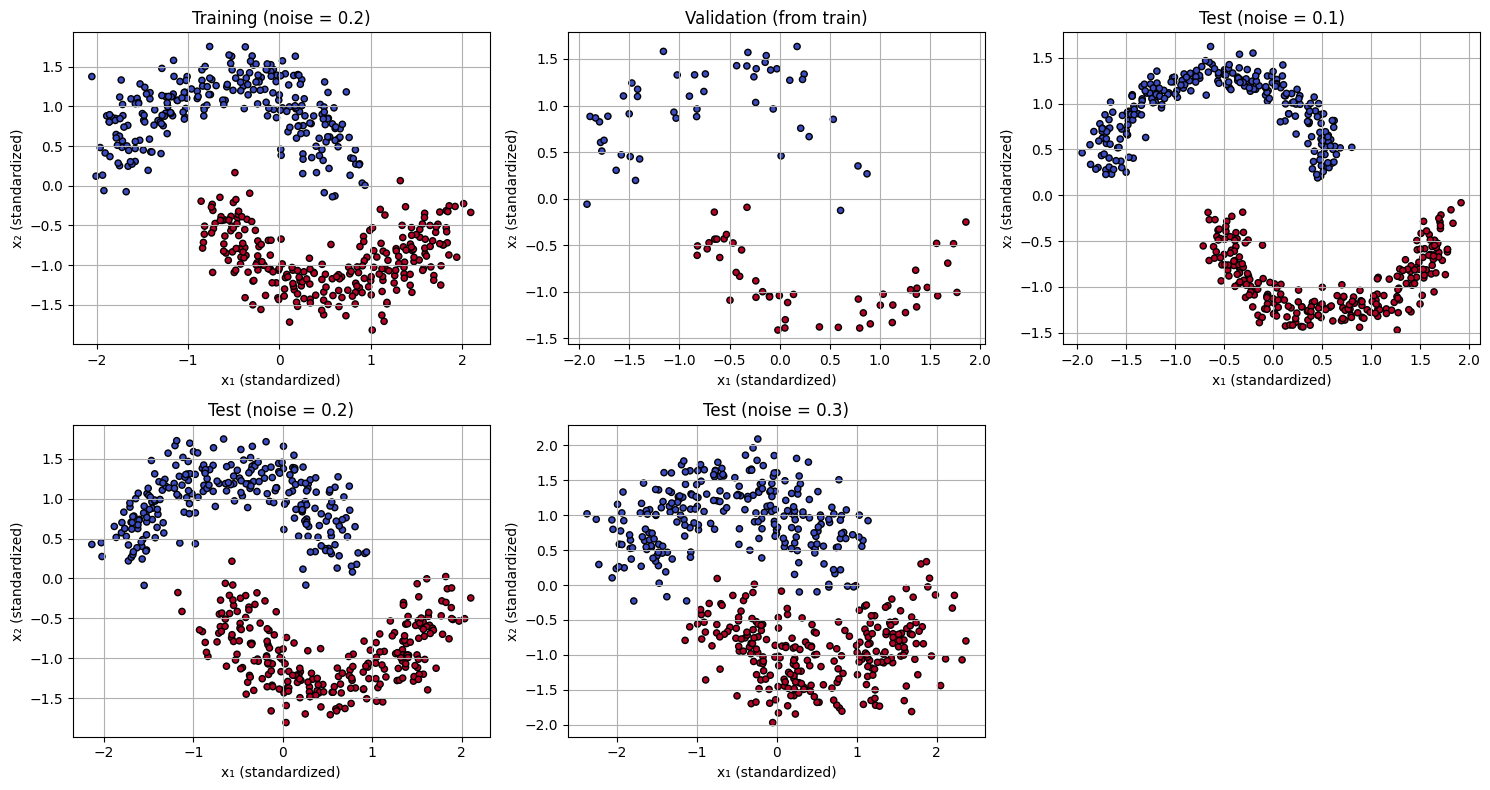

Train: (400, 2) (400,)
Val: (100, 2) (100,)
Test (noise=0.1): (500, 2)
Test (noise=0.2): (500, 2)
Test (noise=0.3): (500, 2)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ----------------------------
# Function to create Make-Moons dataset (no sklearn)
# ----------------------------
def make_moons_custom(n_samples=1000, noise=0.2, seed=None):
    if seed is not None:
        np.random.seed(seed)
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out

    # Outer (upper) moon
    outer_circ_x = np.cos(np.linspace(0, np.pi, n_samples_out))
    outer_circ_y = np.sin(np.linspace(0, np.pi, n_samples_out))
    X_outer = np.column_stack([outer_circ_x, outer_circ_y])
    y_outer = np.zeros(n_samples_out, dtype=int)

    # Inner (lower) moon
    inner_circ_x = 1 - np.cos(np.linspace(0, np.pi, n_samples_in))
    inner_circ_y = -np.sin(np.linspace(0, np.pi, n_samples_in)) - 0.5
    X_inner = np.column_stack([inner_circ_x, inner_circ_y])
    y_inner = np.ones(n_samples_in, dtype=int)

    # Combine
    X = np.vstack([X_outer, X_inner])
    y = np.hstack([y_outer, y_inner])

    # Add Gaussian noise
    X += np.random.normal(scale=noise, size=X.shape)

    # Shuffle
    idx = np.random.permutation(n_samples)
    X, y = X[idx], y[idx]

    return X, y

# ----------------------------
# Generate datasets
# ----------------------------
seed = 1337
n_train = 500
n_test = 500

# Training data (default noise 0.2)
X_train, y_train = make_moons_custom(n_train, noise=0.2, seed=seed)

# Test sets with different noise
X_test_02, y_test_02 = make_moons_custom(n_test, noise=0.2, seed=seed+1)
X_test_01, y_test_01 = make_moons_custom(n_test, noise=0.1, seed=seed+2)
X_test_03, y_test_03 = make_moons_custom(n_test, noise=0.3, seed=seed+3)

# ----------------------------
# Standardize using train statistics only
# ----------------------------
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_02_std = scaler.transform(X_test_02)
X_test_01_std = scaler.transform(X_test_01)
X_test_03_std = scaler.transform(X_test_03)

# ----------------------------
# Validation split (20% of train)
# ----------------------------
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_std, y_train, test_size=0.2, random_state=seed, stratify=y_train
)

# ----------------------------
# Plot all datasets separately
# ----------------------------
datasets = {
    "Training (noise = 0.2)": (X_train_std, y_train),
    "Validation (from train)": (X_val_split, y_val_split),
    "Test (noise = 0.1)": (X_test_01_std, y_test_01),
    "Test (noise = 0.2)": (X_test_02_std, y_test_02),
    "Test (noise = 0.3)": (X_test_03_std, y_test_03),
}

plt.figure(figsize=(15, 8))
for i, (name, (X, y)) in enumerate(datasets.items(), 1):
    plt.subplot(2, 3, i)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=20, edgecolor="k")
    plt.title(name)
    plt.xlabel("x₁ (standardized)")
    plt.ylabel("x₂ (standardized)")
    plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------
# Dataset summaries
# ----------------------------
print("Train:", X_train_split.shape, y_train_split.shape)
print("Val:", X_val_split.shape, y_val_split.shape)
print("Test (noise=0.1):", X_test_01_std.shape)
print("Test (noise=0.2):", X_test_02_std.shape)
print("Test (noise=0.3):", X_test_03_std.shape)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score

# Prepare data
X_tr, y_tr = torch.tensor(X_train_split, dtype=torch.float32), torch.tensor(y_train_split, dtype=torch.float32)
X_val, y_val = torch.tensor(X_val_split, dtype=torch.float32), torch.tensor(y_val_split, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

# MLP
class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

mlp_es = MLP()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(mlp_es.parameters(), lr=1e-3)

# Training with early stopping
best_val = float('inf')
patience, patience_counter = 50, 0
best_model_state = None

for epoch in range(1000):
    mlp_es.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = mlp_es(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

    # Validation
    mlp_es.eval()
    with torch.no_grad():
        val_preds = mlp_es(X_val).squeeze()
        val_loss = criterion(val_preds, y_val)
    if val_loss < best_val:
        best_val = val_loss
        best_model_state = mlp_es.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopped at epoch {epoch}")
        break

mlp_es.load_state_dict(best_model_state)
val_auc = roc_auc_score(y_val.numpy(), val_preds.numpy())
print("Validation AUROC:", val_auc)


Validation AUROC: 1.0


In [ ]:
l1_grid = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
hidden = 16
results = []

for lam in l1_grid:
    mlp_l1_best = MLP(in_dim=2, hidden=hidden)
    optimizer = torch.optim.Adam(mlp_l1_best.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    for epoch in range(300):
        mlp_l1_best.train()
        optimizer.zero_grad()
        preds = mlp_l1_best(X_tr).squeeze()
        loss = criterion(preds, y_tr)
        l1_penalty = sum(torch.sum(torch.abs(p)) for p in mlp_l1_best.parameters())
        loss = loss + lam * l1_penalty
        loss.backward()
        optimizer.step()

    mlp_l1_best.eval()
    with torch.no_grad():
        val_preds = mlp_l1_best(X_val).squeeze()
        val_auc = roc_auc_score(y_val.numpy(), val_preds.numpy())

    # Layer-wise sparsity (% of near-zero weights)
    sparsity = []
    for name, p in mlp_l1_best.named_parameters():
        if "weight" in name:
            zero_frac = torch.mean((torch.abs(p) < 1e-3).float()).item() * 100
            sparsity.append((name, zero_frac))
    results.append((lam, val_auc, sparsity))

# Report results
for lam, auc, sp in results:
    print(f"λ={lam:.1e} | Val AUROC={auc:.4f}")
    for layer, s in sp:
        print(f"   {layer} sparsity: {s:.1f}%")


λ=1.0e-06 | Val AUROC=0.9956
   net.0.weight sparsity: 0.0%
   net.2.weight sparsity: 0.0%
λ=3.0e-06 | Val AUROC=0.9948
   net.0.weight sparsity: 0.0%
   net.2.weight sparsity: 0.0%
λ=1.0e-05 | Val AUROC=0.9992
   net.0.weight sparsity: 0.0%
   net.2.weight sparsity: 0.0%
λ=3.0e-05 | Val AUROC=0.9892
   net.0.weight sparsity: 0.0%
   net.2.weight sparsity: 0.0%
λ=1.0e-04 | Val AUROC=0.9888
   net.0.weight sparsity: 0.0%
   net.2.weight sparsity: 0.0%
λ=3.0e-04 | Val AUROC=0.9888
   net.0.weight sparsity: 0.0%
   net.2.weight sparsity: 0.0%


In [ ]:
l2_grid = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
best_auc, best_l2 = 0, None

for lam in l2_grid:
    mlp_l2_best = MLP()
    optimizer = torch.optim.Adam(mlp_l2_best.parameters(), lr=1e-3, weight_decay=lam)
    criterion = nn.BCELoss()
    for epoch in range(300):
        optimizer.zero_grad()
        preds = mlp_l2_best(X_tr).squeeze()
        loss = criterion(preds, y_tr)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        val_preds = mlp_l2_best(X_val).squeeze()
        val_auc = roc_auc_score(y_val.numpy(), val_preds.numpy())
    print(f"L2={lam:.1e}, Val AUROC={val_auc:.4f}")
    if val_auc > best_auc:
        best_auc, best_l2 = val_auc, lam

print(f"Best L2={best_l2:.1e}, AUROC={best_auc:.4f}")


L2=1.0e-06, Val AUROC=0.9860
L2=1.0e-05, Val AUROC=0.9952
L2=1.0e-04, Val AUROC=0.9944
L2=1.0e-03, Val AUROC=0.9944
L2=1.0e-02, Val AUROC=0.9908
Best L2=1.0e-05, AUROC=0.9952


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# Expand features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_split)
X_val_poly = poly.transform(X_val_split)

# Train logistic regression
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train_poly, y_train_split)

# Validation AUROC
val_probs = log_reg.predict_proba(X_val_poly)[:, 1]
val_auc = roc_auc_score(y_val_split, val_probs)
print("Validation AUROC (Logistic Poly):", val_auc)


Validation AUROC (Logistic Poly): 0.9992


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Convert test data to torch tensors
def torch_predict(model, X):
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).squeeze().numpy()

# Evaluate function
def evaluate_model(model, X_list, y_list, names):
    accs, aucs = [], []
    for X, y in zip(X_list, y_list):
        preds = torch_predict(model, X)
        accs.append(accuracy_score(y, preds > 0.5))
        aucs.append(roc_auc_score(y, preds))
    return accs, aucs

# For sklearn logistic model
def evaluate_sklearn(model, X_list, y_list):
    accs, aucs = [], []
    for X, y in zip(X_list, y_list):
        p = model.predict_proba(X)[:, 1]
        accs.append(accuracy_score(y, p > 0.5))
        aucs.append(roc_auc_score(y, p))
    return accs, aucs

# Prepare datasets
X_tests = [X_test_02_std, X_test_01_std, X_test_03_std]
y_tests = [y_test_02, y_test_01, y_test_03]
names = ["Noise=0.2", "Noise=0.1", "Noise=0.3"]

# Evaluate all models
models = {
    "MLP EarlyStop": mlp_es,
    "MLP L1": mlp_l1_best,
    "MLP L2": mlp_l2_best
}

results = {}
for name, m in models.items():
    acc, auc = evaluate_model(m, X_tests, y_tests, names)
    results[name] = (acc, auc)

# Logistic Regression
acc, auc = evaluate_sklearn(log_reg, [poly.transform(x) for x in X_tests], y_tests)
results["LogReg Poly"] = (acc, auc)

# Print Table
import pandas as pd
df = pd.DataFrame({
    "Noise=0.1": [r[0][1] for r in results.values()],
    "Noise=0.2": [r[0][0] for r in results.values()],
    "Noise=0.3": [r[0][2] for r in results.values()],
}, index=results.keys())

df["Param Count"] = [sum(p.numel() for p in m.parameters()) if "MLP" in k else len(log_reg.coef_.ravel()) for k, m in models.items()] + [len(log_reg.coef_.ravel())]
print(df)


               Noise=0.1  Noise=0.2  Noise=0.3  Param Count
MLP EarlyStop      1.000      0.998      0.992           65
MLP L1             0.984      0.958      0.948           65
MLP L2             0.982      0.958      0.954           65
LogReg Poly        1.000      0.992      0.976            5


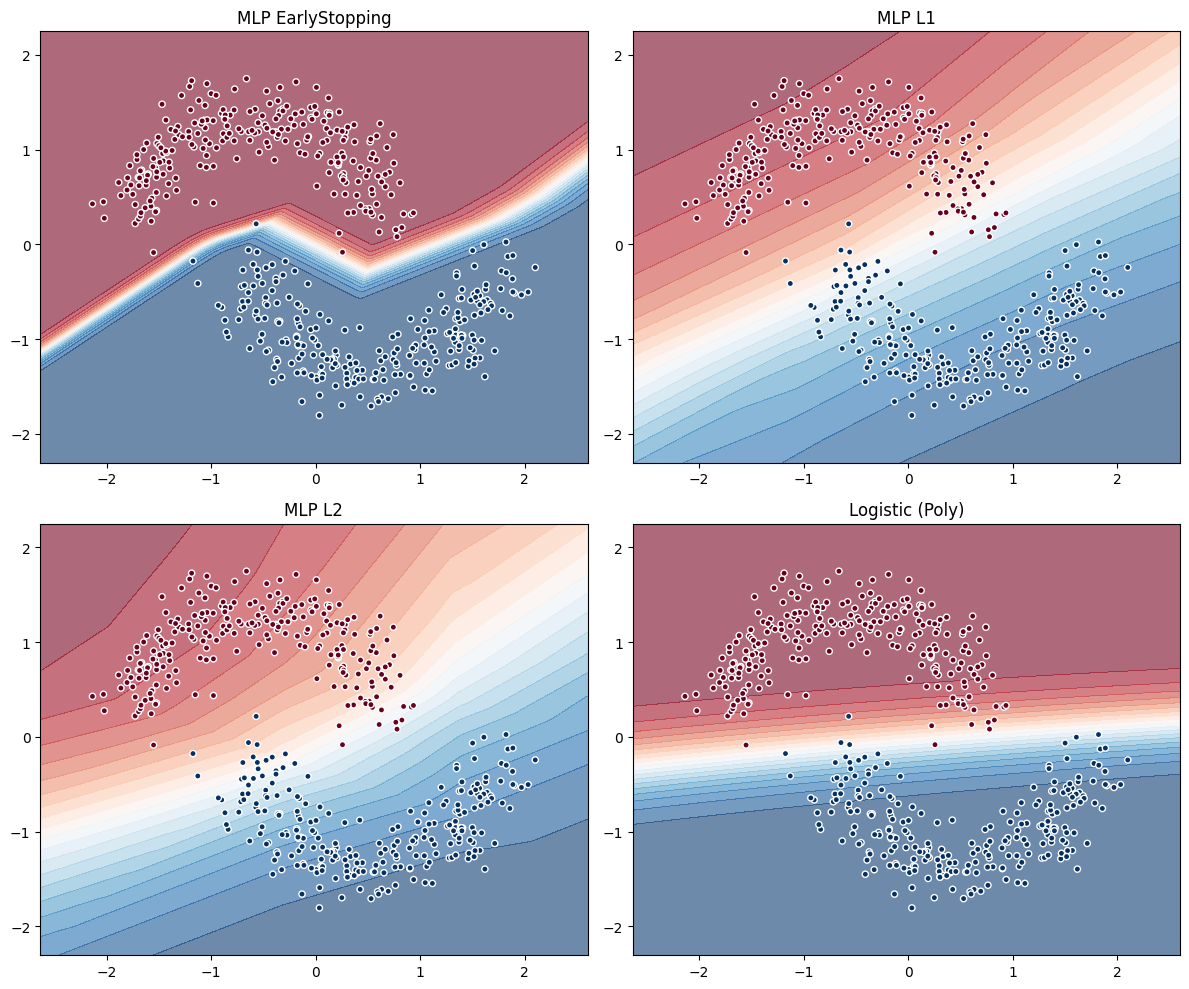

In [ ]:
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title, is_torch=True, poly=None):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if poly:  # for logistic regression
        grid = poly.transform(grid)
        probs = model.predict_proba(grid)[:,1]
    elif is_torch:
        probs = torch_predict(model, grid)
    else:
        probs = model.predict_proba(grid)[:,1]
    Z = probs.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y, cmap="RdBu", edgecolor="white", s=20)
    plt.title(title)

plt.figure(figsize=(12,10))
models_all = [mlp_es, mlp_l1_best, mlp_l2_best, log_reg]
titles = ["MLP EarlyStopping", "MLP L1", "MLP L2", "Logistic (Poly)"]

for i, (m, t) in enumerate(zip(models_all, titles), 1):
    plt.subplot(2, 2, i)
    if "Logistic" in t:
        plot_decision_boundary(m, X_test_02_std, y_test_02, t, is_torch=False, poly=poly)
    else:
        plot_decision_boundary(m, X_test_02_std, y_test_02, t)
plt.tight_layout()
plt.show()


## Discussion Summary

### Effect of L1 Regularization
- Encourages **sparsity** — many weights become nearly zero.
- Results in **jagged or piecewise** decision boundaries because only a few neurons/features stay active.
- Higher λ → the model relies on fewer neurons/features, improving interpretability but sometimes hurting smoothness.

### Effect of L2 Regularization
- Distributes the penalty **smoothly across all weights**, discouraging large ones but keeping all active.
- Produces **smoother decision boundaries** and improves the **margin** between classes.
- Helps prevent overfitting but **does not create true sparsity** (no weights driven exactly to zero).


In [ ]:
# Create imbalanced dataset (70:30)
from collections import Counter

mask_class0 = y_train == 0
mask_class1 = y_train == 1
n0 = int(0.7 * len(y_train))
n1 = len(y_train) - n0
X_train_imb = np.vstack([X_train[mask_class0][:n0], X_train[mask_class1][:n1]])
y_train_imb = np.hstack([y_train[mask_class0][:n0], y_train[mask_class1][:n1]])

# Standardize again
scaler_imb = StandardScaler()
X_train_imb_std = scaler_imb.fit_transform(X_train_imb)
X_test_bal = scaler_imb.transform(X_test_02)

# Train MLP quickly
model_imb = MLP()
opt = torch.optim.Adam(model_imb.parameters(), lr=1e-3)
crit = nn.BCELoss()
Xti = torch.tensor(X_train_imb_std, dtype=torch.float32)
yti = torch.tensor(y_train_imb, dtype=torch.float32)
for e in range(300):
    opt.zero_grad()
    preds = model_imb(Xti).squeeze()
    loss = crit(preds, yti)
    loss.backward()
    opt.step()

# Evaluate
pred_test = torch_predict(model_imb, X_test_bal)
acc = accuracy_score(y_test_02, pred_test>0.5)
auc = roc_auc_score(y_test_02, pred_test)
print("Imbalanced Training → Test Accuracy:", acc)
print("Imbalanced Training → Test AUROC:", auc)


Imbalanced Training → Test Accuracy: 0.98
Imbalanced Training → Test AUROC: 0.9987520000000001


### Discussion:

- Accuracy may remain high due to bias toward majority class.

- AUROC drops — shows poorer discrimination.

- Balanced training or class-weighted loss can fix this.

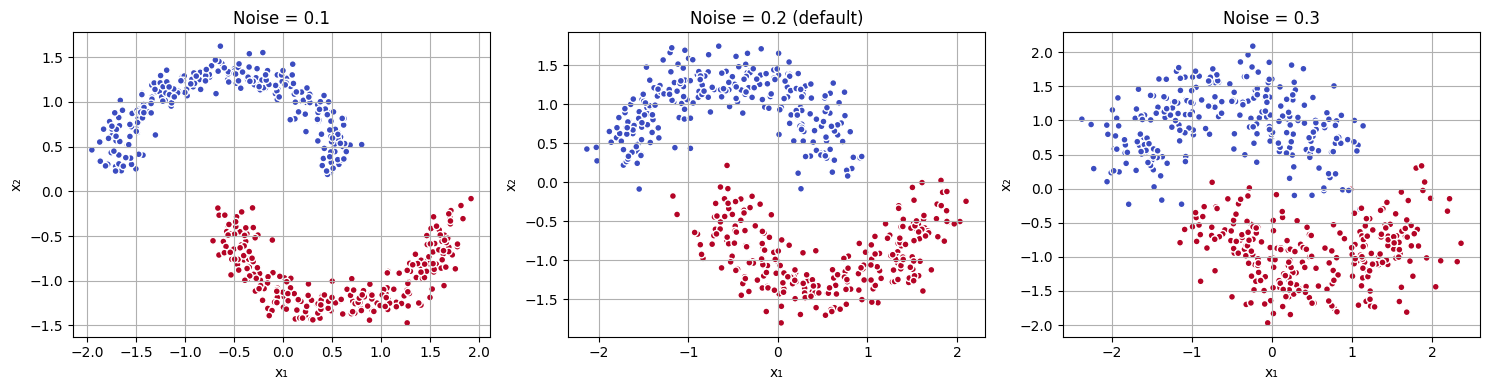

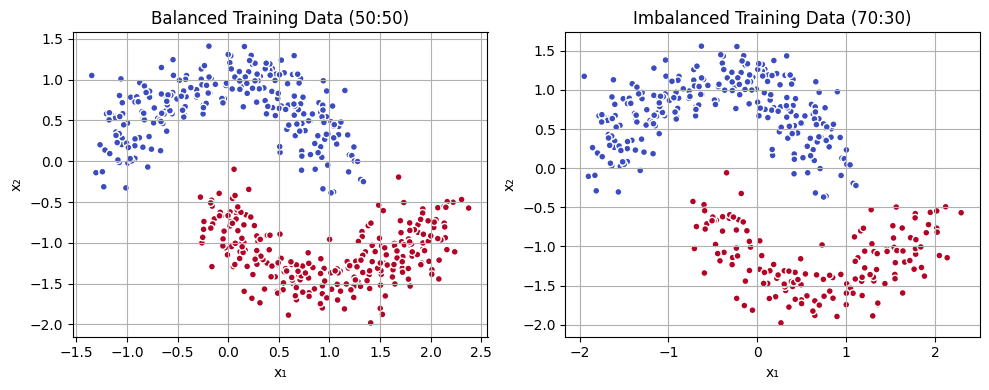

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Utility for plotting datasets
def plot_dataset(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", s=25)
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.grid(True)

# -----------------------------
# 1️⃣ Plot Original Datasets
# -----------------------------
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plot_dataset(X_test_01_std, y_test_01, "Noise = 0.1")
plt.subplot(1, 3, 2)
plot_dataset(X_test_02_std, y_test_02, "Noise = 0.2 (default)")
plt.subplot(1, 3, 3)
plot_dataset(X_test_03_std, y_test_03, "Noise = 0.3")
plt.tight_layout()
plt.show()

# -----------------------------
# 2️⃣ Create Imbalanced Dataset (70:30)
# -----------------------------
mask_class0 = y_train == 0
mask_class1 = y_train == 1
n0 = int(0.7 * len(y_train))
n1 = len(y_train) - n0

X_train_imb = np.vstack([X_train[mask_class0][:n0], X_train[mask_class1][:n1]])
y_train_imb = np.hstack([y_train[mask_class0][:n0], y_train[mask_class1][:n1]])

# Standardize using only imbalanced train stats
scaler_imb = StandardScaler()
X_train_imb_std = scaler_imb.fit_transform(X_train_imb)
X_test_bal = scaler_imb.transform(X_test_02)

# Plot Balanced vs Imbalanced
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_dataset(X_train, y_train, "Balanced Training Data (50:50)")
plt.subplot(1, 2, 2)
plot_dataset(X_train_imb_std, y_train_imb, "Imbalanced Training Data (70:30)")
plt.tight_layout()
plt.show()